In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import fetch_openml
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    StackingClassifier
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [18]:
print("Loading MNIST...")

mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False
)

X = mnist.data.astype(np.float32)
y = mnist.target.astype(int)

print("Completed")
print("Shape:", X.shape)

Loading MNIST...
Completed
Shape: (70000, 784)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (56000, 784)
Test : (14000, 784)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (56000, 784)
Test : (14000, 784)


In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(
    scaler,
    "mnist_scaler.joblib"
)

['mnist_scaler.joblib']

In [24]:
base_models = {

    "lr": (
        LogisticRegression(),
        {
            "C":[0.1,1],
            "max_iter":[1000]
        }
    ),

    "knn": (
        KNeighborsClassifier(),
        {
            "n_neighbors":[3,5]
        }
    ),

    "gnb": (
        GaussianNB(),
        {
            "var_smoothing":[1e-9,1e-8,1e-7]
        }
    ),

    "dt": (
        DecisionTreeClassifier(random_state=42),
        {
            "max_depth":[10]
        }
    ),

    "rf": (
        RandomForestClassifier(random_state=42),
        {
            "n_estimators":[100],
            "max_depth":[20]
        }
    )
}

In [22]:
best_models = {}

for name, (model, params) in base_models.items():

    print("\n" + "="*60)
    print(f"Training {name.upper()}")
    print("="*60)

    grid = GridSearchCV(
        estimator=model,
        param_grid=params,
        cv=3,
        scoring="accuracy",
        n_jobs=-1
    )

    grid.fit(
        X_train_scaled,
        y_train
    )

    best_model = grid.best_estimator_

    best_models[name] = best_model

    print("Best Params:")
    print(grid.best_params_)

    y_pred = best_model.predict(
        X_test_scaled
    )

    acc = accuracy_score(
        y_test,
        y_pred
    )

    print(f"Accuracy: {acc:.4f}")

    joblib.dump(
        best_model,
        f"{name}_best.joblib"
    )


Training LR
Best Params:
{'C': 0.1, 'max_iter': 1000}
Accuracy: 0.9195

Training KNN
Best Params:
{'n_neighbors': 3}
Accuracy: 0.9455

Training GNB
Best Params:
{'var_smoothing': 1e-07}
Accuracy: 0.5446

Training DT
Best Params:
{'max_depth': 10}
Accuracy: 0.8614

Training RF
Best Params:
{'max_depth': 20, 'n_estimators': 100}
Accuracy: 0.9669


In [26]:
estimators = [
    ("lr", best_models["lr"]),
    ("knn", best_models["knn"]),
    ("gnb", best_models["gnb"]),
    ("dt", best_models["dt"]),
    ("rf", best_models["rf"])
]

In [27]:
meta_model = LogisticRegression(
    max_iter=3000,
    n_jobs=-1
)

In [28]:
stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model,
    cv=5,
    stack_method="predict_proba",
    n_jobs=-1
)

In [29]:
print("Training Stacking Ensemble...")

stack_model.fit(
    X_train_scaled,
    y_train
)

joblib.dump(
    stack_model,
    "mnist_stacking.joblib"
)

Training Stacking Ensemble...


Exception ignored in: <function ResourceTracker.__del__ at 0x1076d1bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


['mnist_stacking.joblib']

In [30]:
y_pred = stack_model.predict(
    X_test_scaled
)

acc = accuracy_score(
    y_test,
    y_pred
)

print(f"\nStacking Accuracy: {acc:.4f}")

print(
    classification_report(
        y_test,
        y_pred
    )
)


Stacking Accuracy: 0.9749
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1381
           1       0.99      0.99      0.99      1575
           2       0.97      0.97      0.97      1398
           3       0.97      0.97      0.97      1428
           4       0.98      0.97      0.98      1365
           5       0.98      0.97      0.97      1263
           6       0.98      0.98      0.98      1375
           7       0.97      0.97      0.97      1459
           8       0.97      0.97      0.97      1365
           9       0.96      0.95      0.96      1391

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



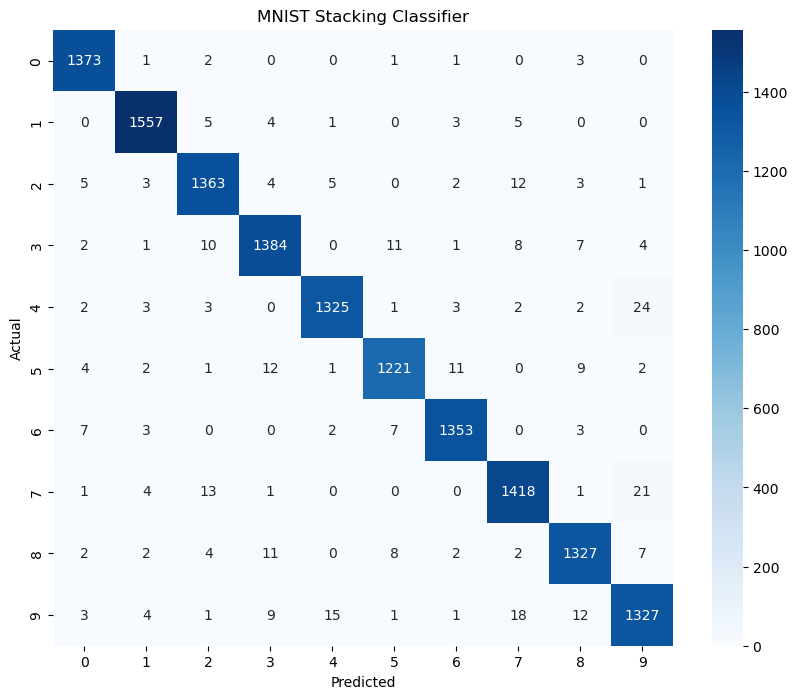

In [31]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("MNIST Stacking Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [32]:
for i in range(10):
    print(f"Image {i} → Predicted Digit: {y_pred[i]}")

Image 0 → Predicted Digit: 7
Image 1 → Predicted Digit: 3
Image 2 → Predicted Digit: 1
Image 3 → Predicted Digit: 1
Image 4 → Predicted Digit: 2
Image 5 → Predicted Digit: 5
Image 6 → Predicted Digit: 9
Image 7 → Predicted Digit: 8
Image 8 → Predicted Digit: 8
Image 9 → Predicted Digit: 1


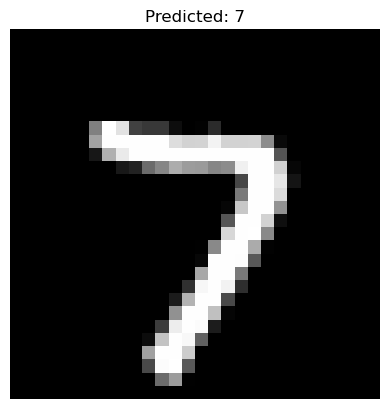

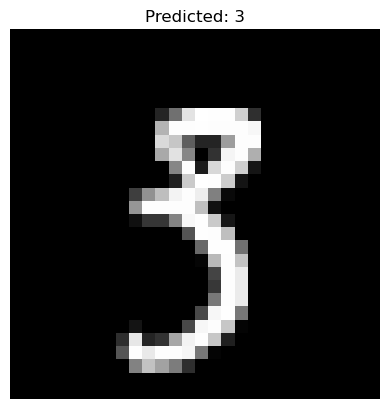

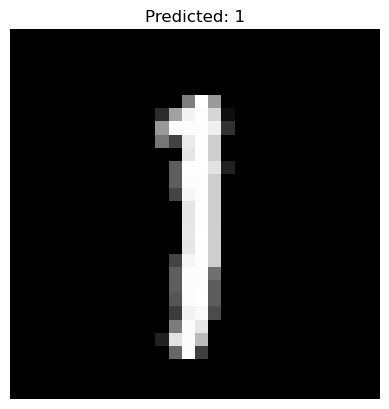

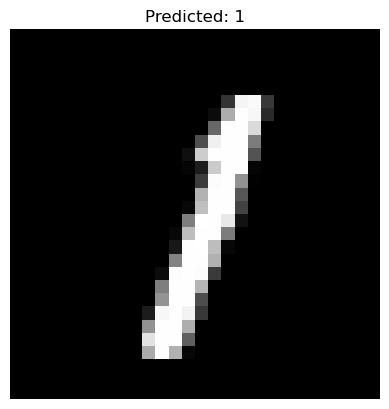

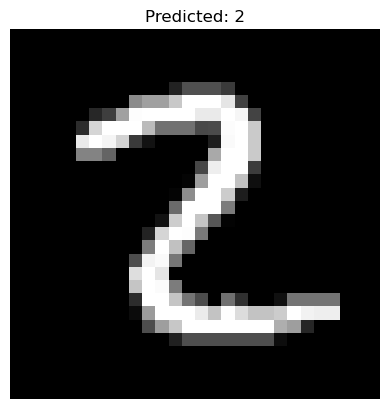

In [33]:
import matplotlib.pyplot as plt

for i in range(5):
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Predicted: {y_pred[i]}")
    plt.axis("off")
    plt.show()